## Importy 

In [29]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms

from classification.models import CytologyClassifier
from segmentation.features import extract_features
from segmentation.modelsUnet import UNet4Levels, UNet, predict_masks

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

## FUNKCJE FUZJI 

In [30]:
def fuse_product(p1, p2, eps=1e-9):
    p = (p1+eps) * (p2+eps)
    return p / p.sum()

def fuse_sum(p1, p2, eps=1e-9):
    p = (p1 + eps) + (p2 + eps)
    return p / p.sum()
    
def R1(p): return 1.0 - np.exp(-((p-1.0)**2)/2.0)
def R2(p): return 1.0 - np.tanh(((p-1.0)**2)/2.0)


def fuse_rank(p1, p2):
    conf_1 = 1.0 - (R1(p1) * R2(p1))  
    conf_2 = 1.0 - (R1(p2) * R2(p2))
    total_conf = conf_1 + conf_2
    w_1 = conf_1 / (total_conf + 1e-9)
    w_2 = conf_2 / (total_conf + 1e-9)
    p = w_1 * p1 + w_2 * p2
    return p / p.sum()

def entropy(p):
    return -(p * np.log(p + 1e-9)).sum()

def fuse_dynamic(p1, p2):
    e1, e2 = entropy(p1), entropy(p2)
    w1 = 1 / (e1 + 1e-9)
    w2 = 1 / (e2 + 1e-9)
    p = (w1 * p1 + w2 * p2) / (w1 + w2)
    return p


## ŁADOWANIE MODELI 

In [31]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  

RESNET_WEIGHTS = r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth'
ARCHITECTURE =  'resnet18' 
# UNET_WEIGHTS = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet4_cell_nucleus_4_50_1310.pth"

UNET_WEIGHTS = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_batch16_1_11.pth"
ML_MODEL_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_311.pkl"

# RESNET
resnet_clf = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
resnet_clf.load(RESNET_WEIGHTS)
resnet_clf.model.eval().to(device)

# U-Net
unet = UNet(in_channels=3, out_channels=2)  
unet.load_state_dict(torch.load(UNET_WEIGHTS, map_location='cpu'))
unet.eval().to(device)

# ML + enkoder
ml_model = joblib.load(ML_MODEL_PATH)['model']
ml_encoder = joblib.load(ML_MODEL_PATH)['label_encoder']


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## FUNKCJE POMOCNICZE

In [32]:

def preprocess_image_for_resnet(img_pil: Image.Image) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return tfm(img_pil)

def preprocess_image_for_unet(img_pil: Image.Image, size: int = 256) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),  # [0,1]
    ])
    return tfm(img_pil)

@torch.inference_mode()
def predict_resnet_probs(model_or_wrapper, image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    x = preprocess_image_for_resnet(img).unsqueeze(0).to(device)

    net = getattr(model_or_wrapper, "model", model_or_wrapper)
    net.eval()
    logits = net(x)                   

    probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    return probs


def select_best_nucleus(mask: np.ndarray, image_shape=None) -> np.ndarray:
    m = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(m)

    if image_shape is None:
        h, w = m.shape
    else:
        h, w = image_shape
    center = np.array([w // 2, h // 2])

    best_score, best_contour = -np.inf, None
    for cnt in contours:
        if len(cnt) < 5:
            continue
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (MA, ma), angle = ellipse
        if MA == 0 or ma == 0:
            continue
        owalnosc = min(MA, ma) / max(MA, ma)
        nucleus_center = np.array([x, y])
        dist_to_center = np.linalg.norm(nucleus_center - center)
        score = owalnosc / (dist_to_center + 1e-5)
        if score > best_score:
            best_score, best_contour = score, cnt

    out = np.zeros_like(m, dtype=np.uint8)
    if best_contour is not None:
        cv2.drawContours(out, [best_contour], -1, 255, thickness=-1)
    return out 

FEATURE_NAMES = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']

def predict_ml_probs(model, input_features: dict) -> np.ndarray:
    try:
        X_new = pd.DataFrame([[input_features[f] for f in FEATURE_NAMES]], columns=FEATURE_NAMES)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    probs = model.predict_proba(X_new)[0].astype(np.float32)  
    return probs


def run_pipeline(image_path: str, fuse_func) -> dict:
    probs_resnet = predict_resnet_probs(resnet_clf, image_path)  

    img_pil = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_image_for_unet(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    masks = predict_masks(unet, image_tensor, device=device, threshold_nuclei=0.4, threshold_cell=0.6)
    cell_mask = (masks[0] > 0).astype(np.uint8)
    nucleus_mask = (masks[1] > 0).astype(np.uint8)
    best_nucleus = select_best_nucleus(nucleus_mask, image_shape=np.array(img_pil).shape[:2])

    feat_dict = extract_features(best_nucleus, cell_mask)
    probs_ml = predict_ml_probs(ml_model, feat_dict) 

    fused = fuse_func(probs_resnet, probs_ml)
    pred_idx = int(np.argmax(fused))
    pred_label = CLASS_NAMES[pred_idx]
    
    assert probs_resnet.shape == (3,), f"VGG ma zły kształt: {probs_resnet.shape}"
    assert probs_ml.shape == (3,), f"ML ma zły kształt: {probs_ml.shape}"
    
    fused = fuse_func(probs_resnet, probs_ml)

    return {
        "resnet_probs": np.round(probs_resnet, 3),
        "ml_probs": np.round(probs_ml, 3),
        "fused_scores": np.round(fused, 3),
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "best_nucleus_mask": nucleus_mask,
        "cell_mask": cell_mask,
        "features": feat_dict
    }


## Metryki

In [33]:

def metrics_and_plots(fuse_func):
    y_true, y_pred, y_scores = [], [], []  

    test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
    valid_ext = (".bmp", ".jpg", ".jpeg", ".png")

    for class_name in os.listdir(test_root):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(valid_ext):
                continue

            image_path = os.path.join(class_dir, fname)
            result = run_pipeline(image_path, fuse_func)

            y_true.append(class_name)                 
            y_pred.append(result["pred_label"])       
            y_scores.append(result["fused_scores"])   

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)   

    CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']

    # --- metryki ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy : {acc:.5f}")
    print(f"Precision: {prec:.5f}")
    print(f"Recall   : {rec:.5f}")
    print(f"F1-score : {f1:.5f}")

    # --- confusion matrix (znormalizowana) ---
    cm_norm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.OrRd)
    plt.title(f"Confusion Matrix (Fusion, normalized) - {fuse_func.__name__}")
    plt.show()

    # --- ROC i AUC ---
    hex_colors = [
        "#b49e1f", "#ee8931", "#d62728"
    ]

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(CLASS_NAMES):
        y_true_bin = (y_true == cls).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_scores[:, i])
        roc_auc = auc(fpr, tpr)

        color = hex_colors[i % len(hex_colors)]  # „zawijanie”, gdy klas > kolorów
        plt.plot(fpr, tpr, lw=2, color=color, label=f"{cls} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves for all classes - {fuse_func.__name__}")
    plt.legend(loc="lower right")
    plt.show()
    


## Rozkład prawd.

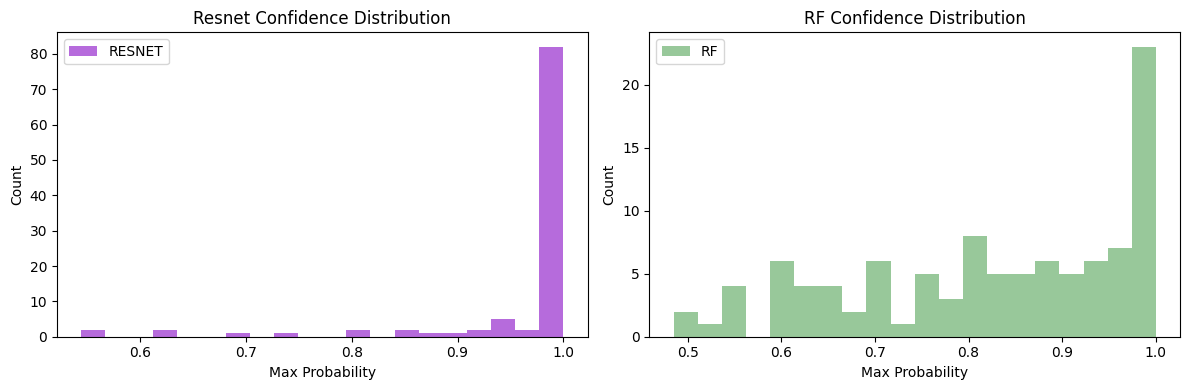

Resnet mean confidence: 0.962
RF mean confidence: 0.823


In [34]:
def analyze_predictions():
    resnet_confs = []
    ml_confs = []
    
    test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
    valid_ext = (".bmp", ".jpg", ".jpeg", ".png")
    
    for class_name in os.listdir(test_root):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(valid_ext):
                continue
            
            image_path = os.path.join(class_dir, fname)
            try:
                result = run_pipeline(image_path, fuse_sum)  
                
                r_max = np.max(result['resnet_probs'])
                ml_max = np.max(result['ml_probs'])
                
                resnet_confs.append(r_max)
                ml_confs.append(ml_max)
            except:
                continue
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(resnet_confs, bins=20, alpha=0.7, label='RESNET', color="#982CCE")
    axes[0].set_xlabel('Max Probability')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Resnet Confidence Distribution')
    axes[0].legend()
    
    axes[1].hist(ml_confs, bins=20, alpha=0.7, label='RF', color="#6CB16F")
    axes[1].set_xlabel('Max Probability')
    axes[1].set_ylabel('Count')
    axes[1].set_title('RF Confidence Distribution')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Resnet mean confidence: {np.mean(resnet_confs):.3f}")
    print(f"RF mean confidence: {np.mean(ml_confs):.3f}")

analyze_predictions()

## TESTY 

In [35]:
import random
from collections import defaultdict

TEST_ROOT = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
VALID_EXT = (".bmp", ".jpg", ".jpeg", ".png")

def list_test_images(test_root, valid_ext=VALID_EXT, per_class=1, max_total=None, shuffle=True, seed=42):
    rng = random.Random(seed)
    images = []

    for class_name in sorted(os.listdir(test_root)):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue

        files = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_ext)]
        if shuffle:
            rng.shuffle(files)

        for f in files[:per_class]:
            images.append((os.path.join(class_dir, f), class_name))

    if shuffle:
        rng.shuffle(images)

    if max_total is not None:
        images = images[:max_total]

    return images


def quick_diagnostic_test_multi(per_class=1, max_total=None):
    test_items = list_test_images(TEST_ROOT, VALID_EXT, per_class=per_class, max_total=max_total)

    if not test_items:
        print("Brak obrazów do testu. Sprawdź ścieżkę i rozszerzenia.")
        return

    fuse_funcs = [fuse_sum, fuse_product, fuse_dynamic, fuse_rank]

    correct = defaultdict(int)
    total = defaultdict(int)

    for img_path, true_cls in test_items:
        print(f"\n=== Testing: {img_path} (true: {true_cls}) ===")

        for fuse_func in fuse_funcs:
            try:
                result = run_pipeline(img_path, fuse_func)

                pred = result['pred_label']
                is_ok = (pred == true_cls)

                total[fuse_func.__name__] += 1
                correct[fuse_func.__name__] += int(is_ok)

                print(f"\n{'-'*50}")
                print(f"Fusion:   {fuse_func.__name__}")
                print(f"True:     {true_cls}")
                print(f"Pred:     {pred}  [{'OK' if is_ok else 'ERR'}]")
                print(f"RESNET:      {result['resnet_probs']}")
                print(f"ML:      {result['ml_probs']}")
                print(f"Fused:    {result['fused_scores']}")
            except Exception as e:
                print(f"[WARN] Błąd dla {fuse_func.__name__} na {img_path}: {e}")

    print("\n" + "="*60)
    print("PODSUMOWANIE TRAFNOŚCI (accuracy)")
    print("="*60)
    for name in [f.__name__ for f in fuse_funcs]:
        if total[name] > 0:
            acc = correct[name] / total[name]
            print(f"{name:20s}: {correct[name]}/{total[name]}  (acc = {acc:.3f})")
        else:
            print(f"{name:20s}: brak prób")


quick_diagnostic_test_multi(per_class=3, max_total=None)



=== Testing: C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\HSIL\19b_5_aug0.png (true: HSIL) ===

--------------------------------------------------
Fusion:   fuse_sum
True:     HSIL
Pred:     HSIL  [OK]
RESNET:      [0.991 0.008 0.   ]
ML:      [0.909 0.091 0.   ]
Fused:    [0.95 0.05 0.  ]

--------------------------------------------------
Fusion:   fuse_product
True:     HSIL
Pred:     HSIL  [OK]
RESNET:      [0.991 0.008 0.   ]
ML:      [0.909 0.091 0.   ]
Fused:    [0.999 0.001 0.   ]

--------------------------------------------------
Fusion:   fuse_dynamic
True:     HSIL
Pred:     HSIL  [OK]
RESNET:      [0.991 0.008 0.   ]
ML:      [0.909 0.091 0.   ]
Fused:    [0.979 0.021 0.   ]

--------------------------------------------------
Fusion:   fuse_rank
True:     HSIL
Pred:     HSIL  [OK]
RESNET:      [0.991 0.008 0.   ]
ML:      [0.909 0.091 0.   ]
Fused:    [0.95 0.05 0.  ]

=== Testing: C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_singl

Accuracy : 0.94175
Precision: 0.93796
Recall   : 0.93796
F1-score : 0.93796


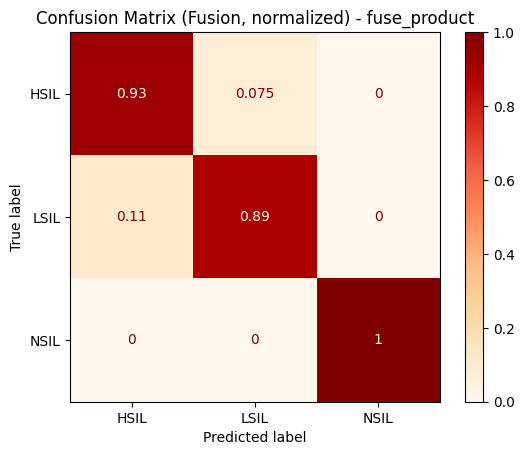

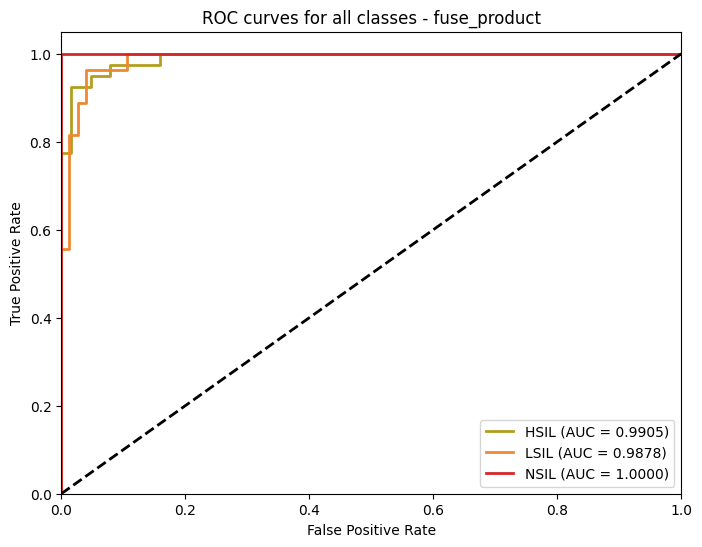

In [36]:
metrics_and_plots(fuse_product)

Accuracy : 0.95146
Precision: 0.94997
Recall   : 0.94630
F1-score : 0.94798


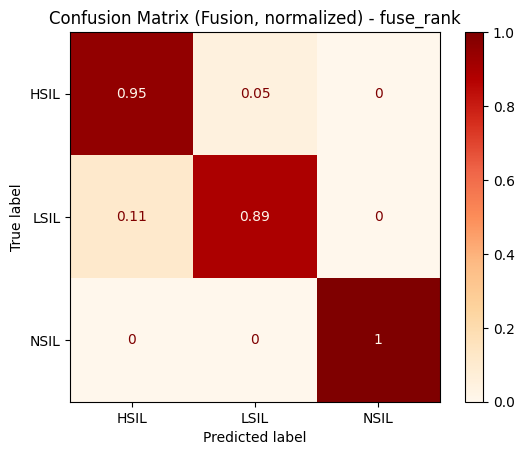

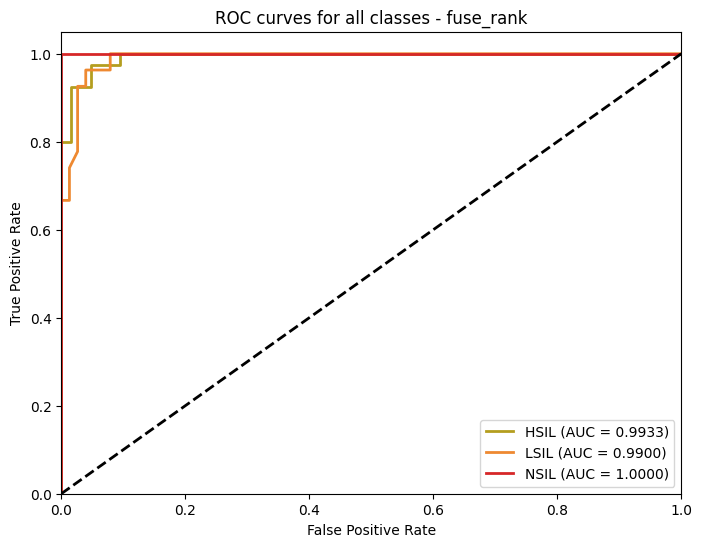

In [37]:
metrics_and_plots(fuse_rank)

Accuracy : 0.95146
Precision: 0.94997
Recall   : 0.94630
F1-score : 0.94798


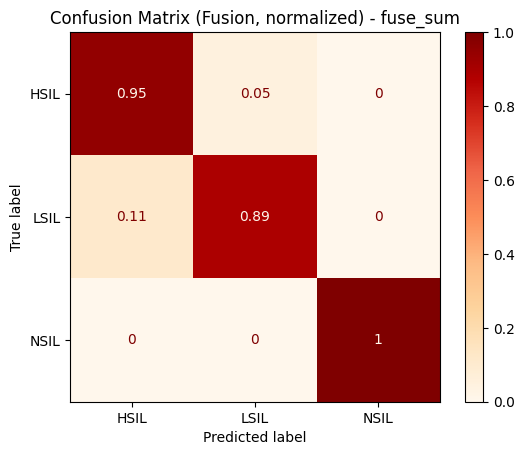

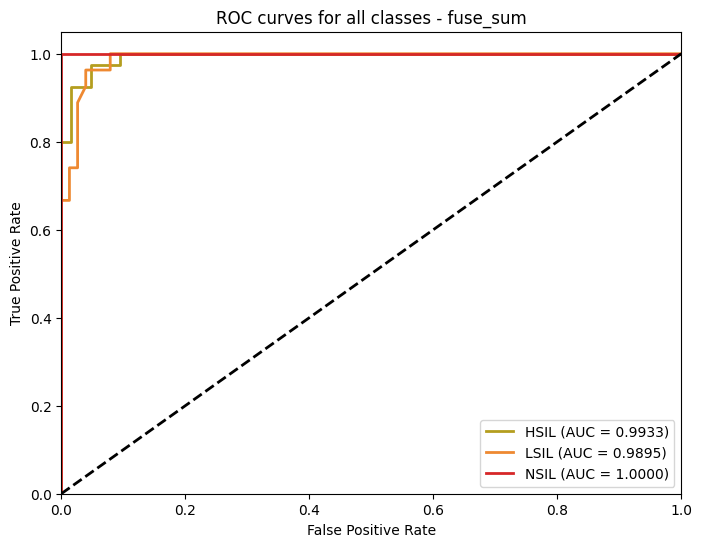

In [38]:
metrics_and_plots(fuse_sum)

Accuracy : 0.95146
Precision: 0.94997
Recall   : 0.94630
F1-score : 0.94798


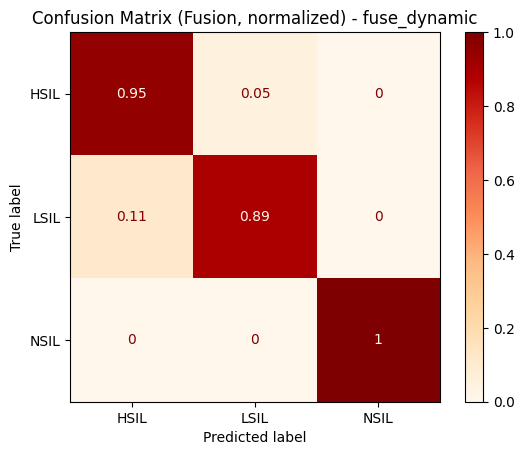

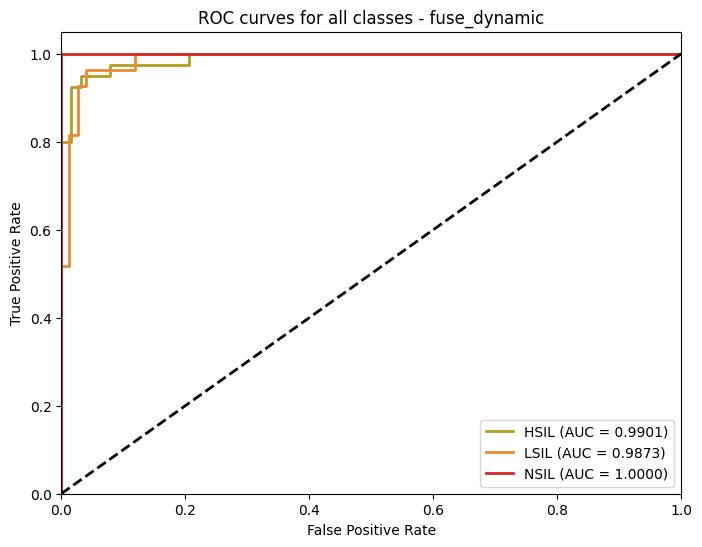

In [39]:
metrics_and_plots(fuse_dynamic)

In [40]:
import os
import pandas as pd

fuse_funcs = {
    "sum": fuse_sum,
    "product": fuse_product,
    "dynamic": fuse_dynamic,
}

y_true = []

all_preds = {name: [] for name in fuse_funcs.keys()}
all_scores = {name: [] for name in fuse_funcs.keys()}

test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
valid_ext = (".bmp", ".jpg", ".jpeg", ".png")

for class_name in os.listdir(test_root):
    class_dir = os.path.join(test_root, class_name)
    if not os.path.isdir(class_dir):
        continue

    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(valid_ext):
            continue

        image_path = os.path.join(class_dir, fname)

        y_true.append(class_name)

        for name, func in fuse_funcs.items():
            result = run_pipeline(image_path, func)

            all_preds[name].append(result["pred_label"])
            all_scores[name].append(result["fused_scores"])  

data = {"y_true": y_true}

for name in fuse_funcs.keys():
    data[f"y_pred_{name}"] = all_preds[name]
    data[f"y_scores_{name}"] = all_scores[name]

df = pd.DataFrame(data)

print(df.head())


  y_true y_pred_sum           y_scores_sum y_pred_product  \
0   HSIL       HSIL      [0.84, 0.16, 0.0]           HSIL   
1   HSIL       HSIL      [0.83, 0.17, 0.0]           HSIL   
2   HSIL       HSIL  [0.938, 0.054, 0.008]           HSIL   
3   HSIL       HSIL  [0.535, 0.278, 0.187]           HSIL   
4   HSIL       HSIL      [0.899, 0.1, 0.0]           HSIL   

       y_scores_product y_pred_dynamic       y_scores_dynamic  
0       [1.0, 0.0, 0.0]           HSIL        [1.0, 0.0, 0.0]  
1       [1.0, 0.0, 0.0]           HSIL        [1.0, 0.0, 0.0]  
2       [1.0, 0.0, 0.0]           HSIL  [0.966, 0.021, 0.013]  
3  [0.933, 0.007, 0.06]           HSIL   [0.905, 0.05, 0.045]  
4       [1.0, 0.0, 0.0]           HSIL    [0.999, 0.001, 0.0]  


In [41]:
df.to_excel("fusion_results.xlsx", index=False)